# SWOT along-track SSH(A) wavenumber spectra:

This notebook takes the output of `compute_pass_spectra()` (from `swot_alongtrack_spectra.py`) -- a dict with one `PassSpectrumResult` per swath, each holding a list of per-segment `SegmentSpectrum` objects -- and:

1. Packs **all retained segments** (both swaths) into a single tidy `xarray.Dataset`, keeping each segment's mean/min/max latitude as coordinates/data variables.
2. Plots the **pass-mean PSD** per swath.
3. Plots **all individual segment PSDs**, colour-coded by latitude, to see how the spectrum varies along the pass.
4. Adds reference power-law slopes (e.g. $k^{-2}$, $k^{-11/3}$) for visual comparison, as is standard in the SWOT/altimetry literature (see e.g. Tchonang et al., SWOT geostrophic velocity validation paper, and Stammer 1997).



In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from swot_analysis.swot_alongtrack_spectra import load_swot_l2, compute_pass_spectra
from swot_analysis import plotting

## 1. Load data and compute spectra

Edit `FILEPATH` and the segment-length / overlap parameters as needed.

In [3]:
data_dir = '/Users/zoecas/Documents/data/'
file = "SWOT_L2_LR_SSH_Expert_045_216_20260131T225821_20260131T234949_PID0_01.nc"

#FILEPATH = "path/to/SWOT_L2_LR_SSH_Basic_*.nc"
SEGMENT_LENGTH_KM = 250.0
OVERLAP = 0.5
MAX_GAP_FRACTION = 0.25

data = load_swot_l2(data_dir+file, ssh_var="ssha_karin_2")

spectra = compute_pass_spectra(
    ssha=data["ssha"],
    latitude=data["latitude"],
    longitude=data["longitude"],
    cross_track_distance=data["cross_track_distance"],
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
)

for swath_name, res in spectra.items():
    print(f"{swath_name}: {res.n_segments_used}/{res.n_segments_total} segments retained")

left: 30/156 segments retained
right: 31/156 segments retained


(-100.0, -60.0)

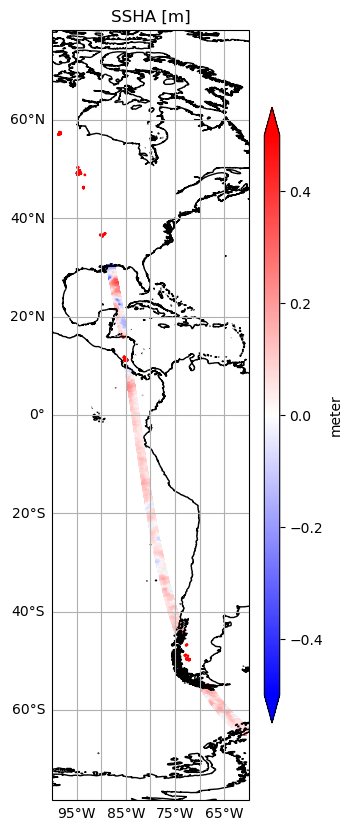

In [4]:
# Whole dataset
title = 'SSHA [m]'
dat = data["ssha"]
lon = data["longitude"]
lat = data["latitude"]
vmin, vmax = -0.5,0.5

#lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
#lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-100,-60)
#ax.pcolormesh(data["longitude"],data["latitude"],data["ssha"],cmap='coolwarm',vmax=0.5)
#ax.set_xlim(260,300);ax.set_ylim(-60,30)

## 2. Pack all segments into a single xarray.Dataset

We build one `Dataset` with dimensions `(segment, wavenumber)`:

- `psd(segment, wavenumber)` -- PSD of every retained segment, both swaths stacked along `segment`.
- `wavenumber(wavenumber)` -- shared wavenumber axis, cycles/km (identical for every segment by construction, since all segments use the same `nperseg`/spacing).
- Per-segment metadata as 1-D data variables indexed by `segment`: `swath`, `lat_mean`, `lat_min`, `lat_max`, `lon_mean`, `along_track_distance_start_km`, `along_track_distance_end_km`, `n_pixels_used`, `valid_fraction`, `gap_filled`.

In [5]:
def segments_to_dataset(spectra: dict) -> xr.Dataset:
    """
    Convert the dict-of-PassSpectrumResult returned by compute_pass_spectra()
    into a single xarray.Dataset stacking every retained segment (both
    swaths) along a `segment` dimension.

    Assumes all segments share the same wavenumber axis (true by
    construction in compute_swath_spectra, since every segment is
    resampled to the same `nperseg`).
    """
    all_segments = []
    wavenumber = None
    for swath_name, res in spectra.items():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        all_segments.extend(res.segments)

    if not all_segments:
        raise ValueError("No segments were retained for either swath; "
                          "nothing to put in a Dataset.")

    psd = np.stack([s.psd for s in all_segments], axis=0)  # (segment, wavenumber)

    ds = xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) power spectral density",
                  "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments],
                      {"long_name": "Segment mean latitude", "units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min for s in all_segments],
                     {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max for s in all_segments],
                     {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments],
                      {"long_name": "Segment mean longitude", "units": "degrees_east"}),
            along_track_distance_start_km=(["segment"],
                [s.along_track_distance_start_km for s in all_segments], {"units": "km"}),
            along_track_distance_end_km=(["segment"],
                [s.along_track_distance_end_km for s in all_segments], {"units": "km"}),
            n_pixels_used=(["segment"], [s.n_pixels_used for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            gap_filled=(["segment"], [bool(s.gap_filled) for s in all_segments]),
            swath=(["segment"], [s.swath for s in all_segments]),
            segment_index=(["segment"], [s.segment_index for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber,
                        {"long_name": "Along-track wavenumber", "units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
        attrs=dict(
            description="Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 LR Expert, "
                         "computed with compute_pass_spectra().",
        ),
    )
    return ds


ds_segments = segments_to_dataset(spectra)
ds_segments

<xarray.Dataset> Size: 37kB
Dimensions:                        (segment: 61, wavenumber: 63)
Coordinates:
  * segment                        (segment) int64 488B 0 1 2 3 ... 57 58 59 60
  * wavenumber                     (wavenumber) float64 504B 0.0 ... 0.2479
Data variables:
    psd                            (segment, wavenumber) float64 31kB 0.1406 ...
    lat_mean                       (segment) float64 488B 28.92 26.7 ... -59.36
    lat_min                        (segment) float64 488B 27.77 25.55 ... -60.52
    lat_max                        (segment) float64 488B 30.08 27.86 ... -58.21
    lon_mean                       (segment) float64 488B 272.5 273.0 ... 293.6
    along_track_distance_start_km  (segment) float64 488B 6.5e+03 ... 1.65e+04
    along_track_distance_end_km    (segment) float64 488B 6.749e+03 ... 1.675...
    n_pixels_used                  (segment) int64 488B 27 27 27 27 ... 26 11 27
    valid_fraction                 (segment) float64 488B 0.7941 ... 0.7712
    gap_filled                     (segment) bool 61B False False ... True True
    swath                          (segment) <U5 1kB 'left' 'left' ... 'right'
    segment_index                  (segment) int64 488B 52 54 55 ... 115 117 132
Attributes:
    description:  Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 ...

## 3. Build another dataset for the pass-mean spectra (one per swath)

In [6]:
def mean_spectra_to_dataset(spectra: dict) -> xr.Dataset:
    """Pack the pass-mean PSD of each swath into a (swath, wavenumber) Dataset."""
    swath_names = [name for name, res in spectra.items() if res.n_segments_used > 0]
    wavenumber = spectra[swath_names[0]].wavenumber
    mean_psd = np.stack([spectra[name].mean_psd for name in swath_names], axis=0)
    n_used = [spectra[name].n_segments_used for name in swath_names]
    n_total = [spectra[name].n_segments_total for name in swath_names]

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(["swath", "wavenumber"], mean_psd,
                      {"long_name": "Pass-mean along-track SSH(A) PSD",
                       "units": "m^2 / (cycles/km)"}),
            n_segments_used=(["swath"], n_used),
            n_segments_total=(["swath"], n_total),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            swath=("swath", swath_names),
        ),
    )


ds_mean = mean_spectra_to_dataset(spectra)
ds_mean

<xarray.Dataset> Size: 2kB
Dimensions:           (swath: 2, wavenumber: 63)
Coordinates:
  * swath             (swath) <U5 40B 'left' 'right'
  * wavenumber        (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    mean_psd          (swath, wavenumber) float64 1kB 0.03599 ... 1.464e-05
    n_segments_used   (swath) int64 16B 30 31
    n_segments_total  (swath) int64 16B 156 156

## 4. Plot: mean PSD
We plot `mean_psd` for `left` and `right` swath. Reference slopes are also added to the plot.

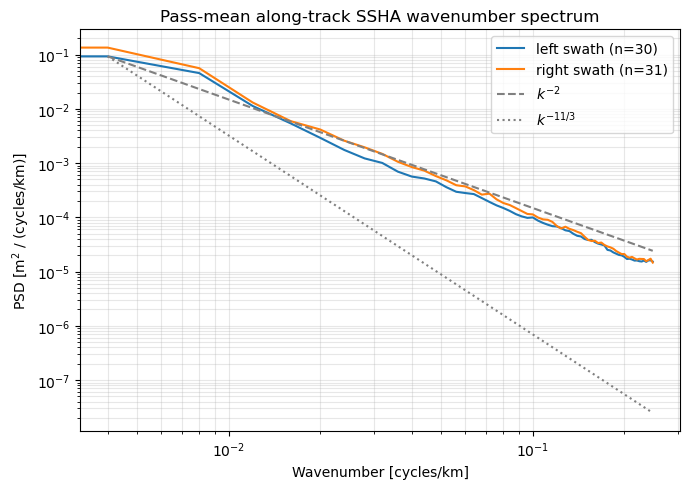

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for swath_name in ds_mean.swath.values:
    da = ds_mean["mean_psd"].sel(swath=swath_name)
    ax.loglog(da.wavenumber, da, label=f"{swath_name} swath "
              f"(n={int(ds_mean['n_segments_used'].sel(swath=swath_name))})")

# reference power-law slopes for visual comparison (anchored at the
# lowest-wavenumber point of the first swath's spectrum)
k_ref = ds_mean.wavenumber.values[1:]
psd_ref = ds_mean["mean_psd"].isel(swath=0).values[1]
k0 = ds_mean.wavenumber.values[1]
for exponent, style in [(-2, "--"), (-11/3, ":")]:
    ax.loglog(k_ref, psd_ref * (k_ref / k0) ** exponent, style, color="gray",
              label=f"$k^{{{exponent:.0f}}}$".replace("-4", "-11/3"))

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("Pass-mean along-track SSHA wavenumber spectrum")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## 5. Plot: Latitudinal dependence
Spectra computed for each segment are plotted. Colormap corresponds to `lat_mean`.

Text(0.5, 0.98, 'Per-segment along-track SSHA wavenumber spectra')

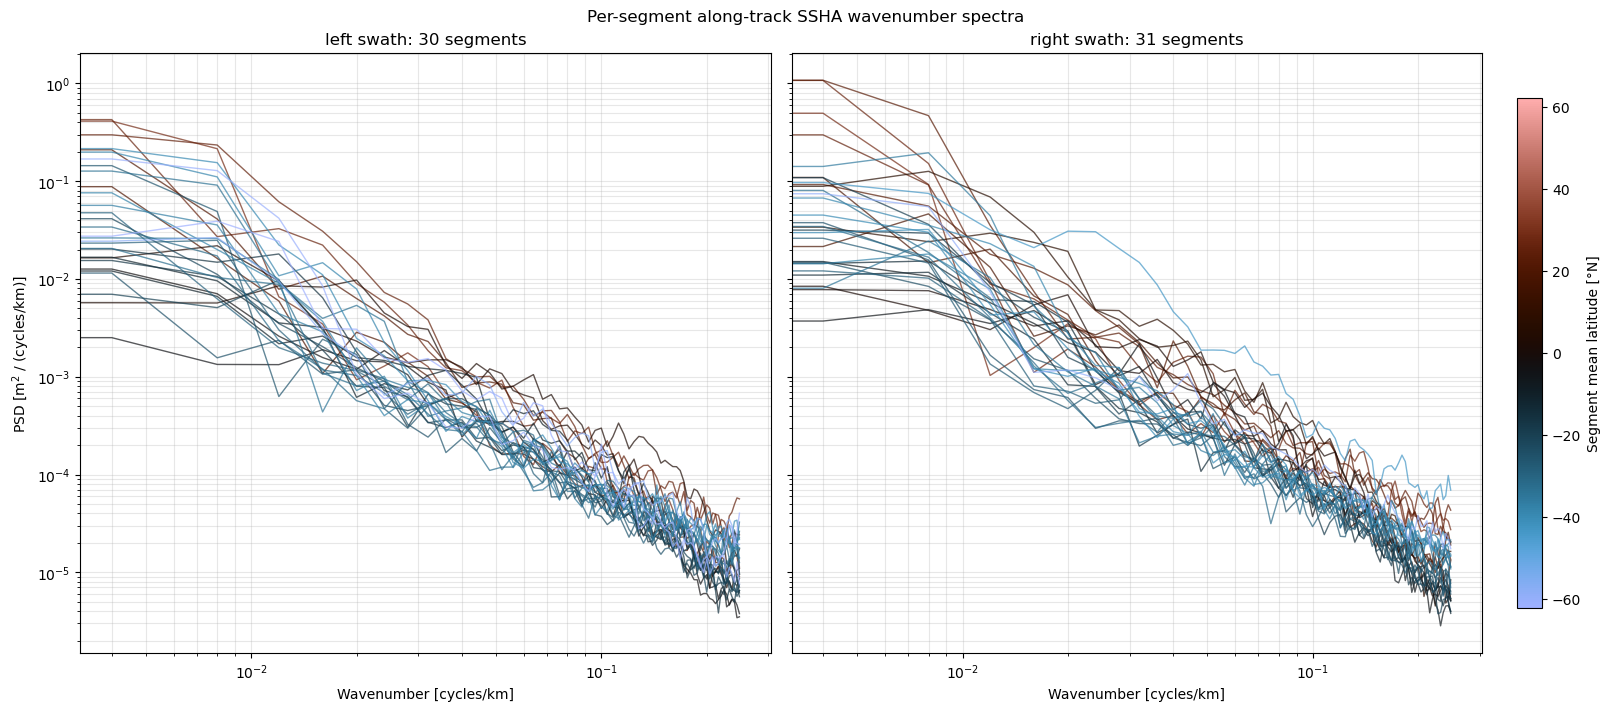

In [14]:
swath_names = list(np.unique(ds_segments["swath"].values))
fig, axes = plt.subplots(1, len(swath_names), figsize=(8 * len(swath_names), 7), sharey=True, layout='constrained')
if len(swath_names) == 1:
    axes = [axes]

cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

for ax, swath_name in zip(axes, swath_names):
    sub = ds_segments.where(ds_segments["swath"] == swath_name, drop=True)
    for i in range(sub.sizes["segment"]):
        seg = sub.isel(segment=i)
        ax.loglog(seg.wavenumber, seg["psd"],
                  color=cmap(norm(float(seg["lat_mean"]))), alpha=0.7, lw=1)
    ax.set_title(f"{swath_name} swath: {sub.sizes['segment']} segments")
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("PSD [m$^2$ / (cycles/km)]")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.85, pad=0.05)
cbar.set_label("Segment mean latitude [°N]")

fig.suptitle("Per-segment along-track SSHA wavenumber spectra")
#fig.tight_layout(rect=[0, 0, 0.93, 0.95])

## 6. Plot: Latitudinal dependence (binned)


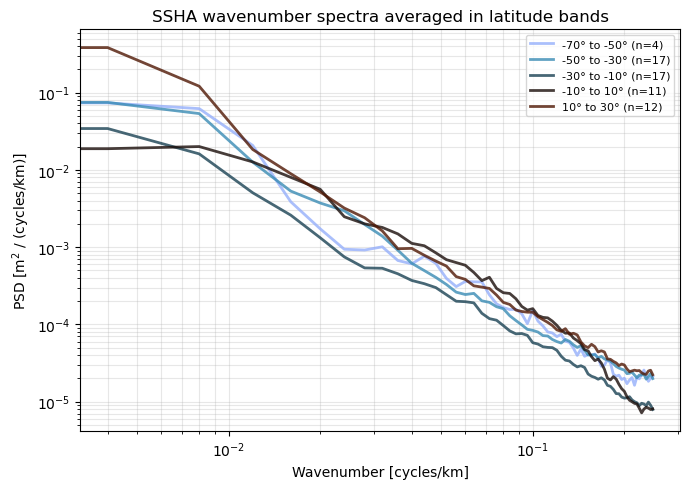

In [9]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range
#LAT_BIN_EDGES = [-70,-40,-10,0,10,40,71]

fig, ax = plt.subplots(figsize=(7, 5))
cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

binned = ds_segments.groupby_bins("lat_mean", LAT_BIN_EDGES)

for lat_bin, group in binned:
    if group.sizes["segment"] == 0:
        continue
    mean_psd = group["psd"].mean(dim="segment")
    bin_center = 0.5 * (lat_bin.left + lat_bin.right)
    #ax.loglog(group.wavenumber, mean_psd,
    #          label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° "
    #                f"(n={group.sizes['segment']})")
    ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2., alpha=.8,
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m$^2$ / (cycles/km)]")
ax.set_title("SSHA wavenumber spectra averaged in latitude bands")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## 7. Plot: Mix of both 5 and 6 sections

Text(0.5, 0.98, 'Per-segment SSHA spectra (alpha-blended) with latitude-binned means overlaid')

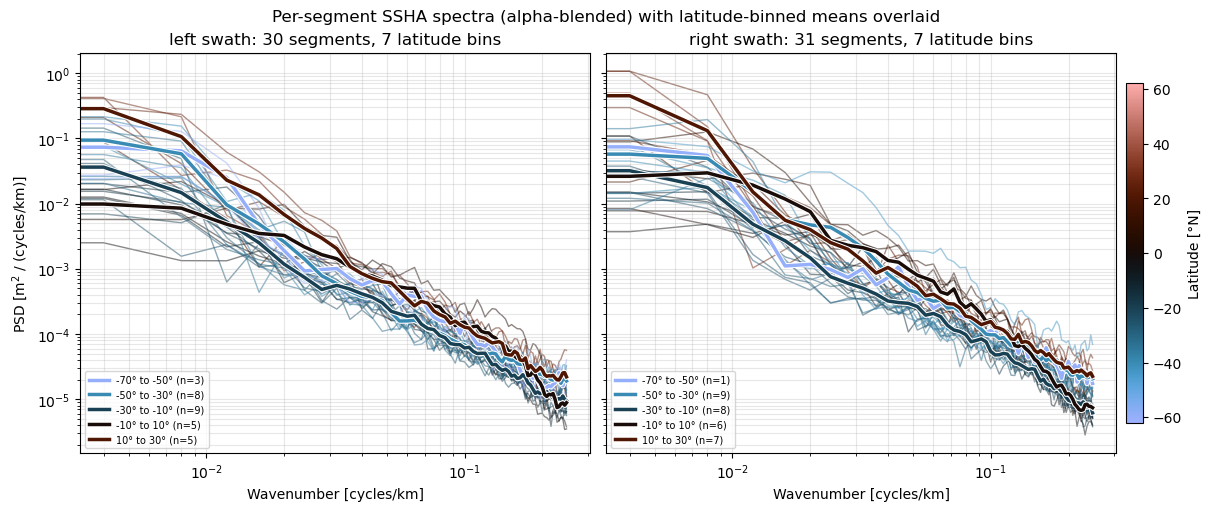

In [13]:
LAT_BIN_EDGES = np.arange(-70, 71, 20)  # adjust to the pass's latitude range

swath_names = list(np.unique(ds_segments["swath"].values))
fig, axes = plt.subplots(1, len(swath_names), figsize=(6 * len(swath_names), 5), sharey=True,layout='constrained')
if len(swath_names) == 1:
    axes = [axes]

# shared colormap/normalisation for BOTH the per-segment lines and the
# latitude-binned mean lines, so colours are directly comparable
cmax = max(np.abs(ds_segments["lat_mean"].min()),np.abs(ds_segments["lat_mean"].max()))
norm = plt.Normalize(vmin=float(-cmax),
                      vmax=float(cmax))
cmap = plt.get_cmap("berlin")

for ax, swath_name in zip(axes, swath_names):
    sub = ds_segments.where(ds_segments["swath"] == swath_name, drop=True)

    # -- layer 1: all individual segments, thin + alpha-blended --
    for i in range(sub.sizes["segment"]):
        seg = sub.isel(segment=i)
        ax.loglog(seg.wavenumber, seg["psd"],
                  color=cmap(norm(float(seg["lat_mean"]))), alpha=0.5, lw=1, zorder=1)

    # -- layer 2: latitude-binned mean spectra, drawn on top --
    binned = sub.groupby_bins("lat_mean", LAT_BIN_EDGES)
    for lat_bin, group in binned:
        if group.sizes["segment"] == 0:
            continue
        mean_psd = group["psd"].mean(dim="segment")
        bin_center = 0.5 * (lat_bin.left + lat_bin.right)
        ax.loglog(group.wavenumber, mean_psd,
                  color=cmap(norm(bin_center)), lw=2.5, alpha=1.0,
                  path_effects=[pe.Stroke(linewidth=4, foreground="white"), pe.Normal()],
                  zorder=2,
                  label=f"{lat_bin.left:.0f}° to {lat_bin.right:.0f}° (n={group.sizes['segment']})")

    ax.set_title(f"{swath_name} swath: {sub.sizes['segment']} segments, "
                 f"{len(LAT_BIN_EDGES) - 1} latitude bins")
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left")

axes[0].set_ylabel("PSD [m$^2$ / (cycles/km)]")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.85, pad=0.02)
cbar.set_label(r"Latitude [°N]")

fig.suptitle("Per-segment SSHA spectra (alpha-blended) with latitude-binned means overlaid")
#fig.tight_layout(rect=[0, 0, 0.93, 0.95])

## 8. Saving datasets

In [11]:
# ds_segments.to_netcdf("swot_pass_segment_spectra.nc")
# ds_mean.to_netcdf("swot_pass_mean_spectra.nc")